In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from cmocean import cm # for oceanography-specific colormaps
from scipy.io import loadmat
import numpy as np
import re
from xml.etree import ElementTree as ET
from matplotlib.path import Path
import pandas as pd
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator

### Functions

In [2]:
##--------------------- Distance to the coast -----------------------##
def _islatlon(lat, lon):
    """
    Rough MATLAB-style range check:  -90 ≤ lat ≤ 90  and  -180 ≤ lon ≤ 360
    """
    return (np.all(lat >= -90) and np.all(lat <= 90) and
            np.all(lon >= -180) and np.all(lon <= 360))


def dist2coast(lati, loni, *, matfile="/gxfs_work/geomar/smomw662/NHCS/Master_Thesis/distance2coast.mat"):
    """
    dist2coast  –  Great-circle distance [km] from any point(s) to the nearest coastline.
    
    Parameters
    ----------
    lati, loni : array-like
        Latitudes and longitudes of the target points (same shape, any dimensionality).
    matfile : str, optional
        Path to the `distance2coast.mat` file containing variables
        `lat`, `lon`, and `D` (pre-computed distance grid).

    Returns
    -------
    di : ndarray
        Array of the same shape as `lati`/`loni` with distances in kilometres.
    """
    # Convert inputs to ndarray, preserve original shape for the return
    lati = np.asanyarray(lati, dtype=float)
    loni = np.asanyarray(loni, dtype=float)

    # --- Error checks (MATLAB narginchk / asserts) ------------------------
    if lati.shape != loni.shape:
        raise ValueError("Dimensions of input coordinates must agree.")
    if not _islatlon(lati, loni):
        raise ValueError(
            "Input coordinates appear to be outside the normal latitude/longitude "
            "ranges. Check inputs (and their order) and try again."
        )

    # --- Wrap any 0↠360 longitudes into -180↠180 --------------------------
    loni = np.where(loni > 180, loni - 360, loni)

    # --- Load coastline-distance grid from .mat ---------------------------
    mat = loadmat(matfile)
    lat = mat["lat"].ravel()        # 1-D vectors
    lon = mat["lon"].ravel()
    D   = mat["D"]                  # 2-D matrix, same dims as (lat, lon)

    # --- Wrap the data set itself for seamless Date-Line interpolation ----
    D_wrap  = np.concatenate([D[:, -5:], D, D[:, :5]], axis=1)  # MATLAB: end-4:end, 1:5
    lon_wrap = np.concatenate([lon[-5:] - 360, lon, lon[:5] + 360])

    # --- Linear 2-D interpolation (RegularGridInterpolator) ---------------
    interp = RegularGridInterpolator(
        (lat, lon_wrap),
        D_wrap.astype(float),
        method="linear",
        bounds_error=False,
        fill_value=np.nan,   # mirror MATLAB’s NaN outside the grid
    )

    # Sample the interpolant at the requested points
    pts = np.column_stack((lati.ravel(), loni.ravel()))
    di  = interp(pts).reshape(lati.shape)

    return di #in km

In [3]:
#### Inshore mask
## kml to struct
import re
from xml.etree import ElementTree as ET
import numpy as np

def kml2struct(kml_file):
    """
    Import a .kml file as a list of dictionary structures with fields:
    Geometry, Name, Description, Lon, Lat, and BoundingBox.
    """
    # Read the KML file
    try:
        with open(kml_file, 'r', encoding='utf-8') as file:
            txt = file.read()
    except Exception as e:
        raise FileNotFoundError(f"Unable to open file {kml_file}: {e}")

    # Regular expression to match Placemark tags
    expr = r"<Placemark.+?>.+?</Placemark>"
    object_strings = re.findall(expr, txt, re.DOTALL)
    
    kml_struct = []

    for obj_str in object_strings:
        # Extract Name
        name_match = re.search(r"<name.*?>(.*?)</name>", obj_str, re.DOTALL)
        name = name_match.group(1).strip() if name_match else "undefined"

        # Extract Description
        desc_match = re.search(r"<description.*?>(.*?)</description>", obj_str, re.DOTALL)
        desc = desc_match.group(1).strip() if desc_match else ""

        # Determine Geometry Type
        geometry = ""
        if "<Point" in obj_str:
            geometry = "Point"
        elif "<LineString" in obj_str:
            geometry = "Line"
        elif "<Polygon" in obj_str:
            geometry = "Polygon"

        # Extract Coordinates
        coord_match = re.search(r"<coordinates.*?>(.*?)</coordinates>", obj_str, re.DOTALL)
        if not coord_match:
            continue  # Skip if no coordinates are found
        coord_str = coord_match.group(1).strip()
        coord_list = np.array([list(map(float, coord.split(','))) for coord in coord_str.split()])

        # Separate Lon, Lat, and handle Polygons
        lon = coord_list[:, 0]
        lat = coord_list[:, 1]
        if geometry == "Polygon":
            # Close the polygon by appending NaN
            lon = np.append(lon, np.nan)
            lat = np.append(lat, np.nan)

        # Create BoundingBox
        bounding_box = [[lon.min(), lat.min()], [lon.max(), lat.max()]]

        # Append to kml_struct
        kml_struct.append({
            "Geometry": geometry,
            "Name": name,
            "Description": desc,
            "Lon": lon,
            "Lat": lat,
            "BoundingBox": bounding_box
        })

    return kml_struct

In [4]:
arch_kml_zona1 = "../../NHCS/hindcast/CROCO_BioEBUS_1990-2010/indices/BK111km.kml"
R1 = kml2struct(arch_kml_zona1)

# Extract Lon and Lat from the first polygon
lonb1 = R1[0]["Lon"]
latb1 = R1[0]["Lat"]

In [5]:
ds_ = xr.open_dataset('../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc', 
                     chunks = {'time':1})
ds_

<xarray.Dataset> Size: 891MB
Dimensions:     (xi_rho: 602, xi_u: 601, eta_rho: 542, eta_v: 541, s_rho: 32,
                 s_w: 33, time: 1, auxil: 4)
Coordinates: (12/13)
  * xi_rho      (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 599.0 600.0 601.0 602.0
  * xi_u        (xi_u) float64 5kB 1.5 2.5 3.5 4.5 ... 598.5 599.5 600.5 601.5
  * eta_rho     (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 540.0 541.0 542.0
  * eta_v       (eta_v) float64 4kB 1.5 2.5 3.5 4.5 ... 538.5 539.5 540.5 541.5
  * s_rho       (s_rho) float64 256B -0.9844 -0.9531 ... -0.04688 -0.01562
  * s_w         (s_w) float64 264B -1.0 -0.9688 -0.9375 ... -0.0625 -0.03125 0.0
    ...          ...
    lat_rho     (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(542, 602), meta=np.ndarray>
    lon_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lat_u       (eta_rho, xi_u) float64 3MB dask.array<chunksize=(542, 601), meta=np.ndarray>
    lon_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
    lat_v       (eta_v, xi_rho) float64 3MB dask.array<chunksize=(541, 602), meta=np.ndarray>
  * time        (time) float32 4B 1.339e+06
Dimensions without coordinates: auxil
Data variables: (12/54)
    spherical   |S1 1B ...
    xl          float64 8B ...
    el          float64 8B ...
    Vtransform  float64 8B ...
    sc_r        (s_rho) float64 256B dask.array<chunksize=(32,), meta=np.ndarray>
    sc_w        (s_w) float64 264B dask.array<chunksize=(33,), meta=np.ndarray>
    ...          ...
    swflux      (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    radsw       (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_rlw   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_lat   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    shflx_sen   (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
    hel         (time, eta_rho, xi_rho) float32 1MB dask.array<chunksize=(1, 542, 602), meta=np.ndarray>
Attributes: (12/57)
    type:           ROMS restart file
    title:          Peru UW Interannual Run
    date:           
    rst_file:       croco_rst.nc
    his_file:       croco_his.nc
    avg_file:       croco_avg.nc
    ...             ...
    gamma2_expl:    Slipperiness parameter
    x_sponge:       0.0
    v_sponge:       0.0
    sponge_expl:    Sponge parameters : extent (m) & viscosity (m2.s-1)
    SRCS:           main.F step.F read_inp.F timers_roms.F init_scalars.F ini...
    CPP-options:    REGIONAL PERU_UW MPI OBC_WEST OBC_NORTH OBC_SOUTH BIOLOGY...

In [6]:
LON, LAT = np.meshgrid(ds_.lon_rho.compute().values[0,:],ds_.lat_rho.compute().values[:,0])
# Create a path from the polygon coordinates
polygon = Path(np.column_stack((lonb1, latb1)))

# Flatten the LON and LAT to create coordinate pairs
lonlat_points = np.column_stack((LON.ravel(), LAT.ravel()))

# Check which points are inside the polygon
mask = polygon.contains_points(lonlat_points).reshape(LON.shape)

# Convert the mask to NaN for the outshore region
inshore_mask = np.where(mask, 1, np.nan)

mask_rho = ds_.mask_rho.values 
mask_nan = np.where(mask_rho, 1, np.nan)

In [7]:
len(inshore_mask)

542

## Data

In [8]:
import glob, xarray as xr

files = sorted(glob.glob('/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y*M*.nc'))
print(len(files), files[:5], files[-5:])

# Peek at first two
for f in files[:3]:
    with xr.open_dataset(f) as ds:
        print(f, ds['bulk_time'].load().values[:3], ds['bulk_time'].load().values[-3:])

432 ['/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M1.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M10.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M11.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M12.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M2.nc'] ['/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y2015M5.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y2015M6.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y2015M7.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y2015M8.nc', '/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y2015M9.nc']
/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y1980M1.nc [-7200000295476 -3600000147738              0] [26748000549

In [9]:
# ds = xr.open_mfdataset('/nfs/ceph_geomar/smomw398/CROCO_BioEBUS_1980_2015/INPUT/croco_blk_ERA5_Y*M*.nc')
# ds

## improve the chunking as it should be 4320 time so a month
ds = xr.open_mfdataset(
    files,
    combine='nested',
    concat_dim='bulk_time',  # name of the time coordinate/dimension to concat
    parallel=True,
    chunks={
        'bulk_time': 100,
        # 'eta_rho': 271,     # Half the spatial dimension
        # 'xi_rho': 301       # Half the spatial dimension
    }
)
# remove duplicates and sort if any
_, index = np.unique(ds['bulk_time'], return_index=True)
ds = ds.isel(bulk_time=np.sort(index))
ds

<xarray.Dataset> Size: 9TB
Dimensions:    (bulk_time: 315580, eta_rho: 542, xi_rho: 602, eta_u: 542,
                xi_u: 601, eta_v: 541, xi_v: 602)
Coordinates:
  * bulk_time  (bulk_time) timedelta64[ns] 3MB -1 days +21:59:59.999704524 .....
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v
Data variables:
    tair       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    rhum       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    prate      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    wspd       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radlw      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radlw_in   (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radsw      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    sustr      (bulk_time, eta_u, xi_u) float64 822GB dask.array<chunksize=(92, 542, 601), meta=np.ndarray>
    svstr      (bulk_time, eta_v, xi_v) float64 822GB dask.array<chunksize=(92, 541, 602), meta=np.ndarray>
    uwnd       (bulk_time, eta_u, xi_u) float64 822GB dask.array<chunksize=(92, 542, 601), meta=np.ndarray>
    vwnd       (bulk_time, eta_v, xi_v) float64 822GB dask.array<chunksize=(92, 541, 602), meta=np.ndarray>
Attributes:
    title:        Peru UW Model
    date:         27-Sep-2023
    grd_file:     /gxfs_work1/fs1/work-geomar/smomw398/croco_tool/croco_tools...
    type:         CROCO heat flux bulk forcing file
    origin_date:  01-Jan-1980 00:00:00
    product:      ERA5

In [10]:
import pandas as pd

origin = np.datetime64('1980-01-01T00:00:00')  # example; choose your true origin
abs_time = origin + ds.bulk_time

# Example: extract calendar year and month with pandas
pdt = pd.DatetimeIndex(abs_time.values.astype('datetime64[ns]'))
year  = xr.DataArray(pdt.year,  coords=ds.bulk_time.coords, dims=ds.bulk_time.dims, name='year')
month = xr.DataArray(pdt.month, coords=ds.bulk_time.coords, dims=ds.bulk_time.dims, name='month')
day   = xr.DataArray(pdt.day,   coords=ds.bulk_time.coords, dims=ds.bulk_time.dims, name='day')
hour   = xr.DataArray(pdt.hour,   coords=ds.bulk_time.coords, dims=ds.bulk_time.dims, name='hour')


In [11]:
ds = ds.assign_coords(
    year = (('bulk_time',), year.values),
    month = (('bulk_time',), month.values),
    day = (('bulk_time',), day.values),
    hour = (('bulk_time',), hour.values),
)

time = xr.DataArray(abs_time.astype('datetime64[ns]'),
                    coords=ds.bulk_time.coords, dims=ds.bulk_time.dims, name='time')

# Add it as a coordinate and keep bulk_time as-is
ds = ds.assign_coords(time=('bulk_time', time.values))

ds

<xarray.Dataset> Size: 9TB
Dimensions:    (bulk_time: 315580, eta_rho: 542, xi_rho: 602, eta_u: 542,
                xi_u: 601, eta_v: 541, xi_v: 602)
Coordinates:
  * bulk_time  (bulk_time) timedelta64[ns] 3MB -1 days +21:59:59.999704524 .....
    year       (bulk_time) int32 1MB 1979 1979 1980 1980 ... 2015 2015 2015 2015
    month      (bulk_time) int32 1MB 12 12 1 1 1 1 1 1 1 1 ... 9 9 9 9 9 9 9 9 9
    day        (bulk_time) int32 1MB 31 31 1 1 1 1 1 1 ... 30 30 30 30 30 30 30
    hour       (bulk_time) int32 1MB 21 22 0 1 2 3 4 4 ... 15 16 16 18 19 19 21
    time       (bulk_time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ....
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v
Data variables:
    tair       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    rhum       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    prate      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    wspd       (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radlw      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radlw_in   (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    radsw      (bulk_time, eta_rho, xi_rho) float64 824GB dask.array<chunksize=(92, 542, 602), meta=np.ndarray>
    sustr      (bulk_time, eta_u, xi_u) float64 822GB dask.array<chunksize=(92, 542, 601), meta=np.ndarray>
    svstr      (bulk_time, eta_v, xi_v) float64 822GB dask.array<chunksize=(92, 541, 602), meta=np.ndarray>
    uwnd       (bulk_time, eta_u, xi_u) float64 822GB dask.array<chunksize=(92, 542, 601), meta=np.ndarray>
    vwnd       (bulk_time, eta_v, xi_v) float64 822GB dask.array<chunksize=(92, 541, 602), meta=np.ndarray>
Attributes:
    title:        Peru UW Model
    date:         27-Sep-2023
    grd_file:     /gxfs_work1/fs1/work-geomar/smomw398/croco_tool/croco_tools...
    type:         CROCO heat flux bulk forcing file
    origin_date:  01-Jan-1980 00:00:00
    product:      ERA5

In [12]:
uwind = xr.Dataset(
    data_vars={
        'u10': (("time", "lat","lon"), ds['uwnd'].data),
        # 'v10':(("time", "lat","lon"), ds['vwnd'].data.transpose(2, 1, 0))
    },
    coords = {
        'lon':ds_.lon_u.compute().values[0,:],
        'lat':ds_.lat_u.compute().values[:,0],
        'time':ds.time.data
}
)

print(uwind)

vwind = xr.Dataset(
    data_vars={
        'v10': (("time", "lat","lon"), ds['vwnd'].data),
        # 'v10':(("time", "lat","lon"), ds['vwnd'].data.transpose(2, 1, 0))
    },
    coords = {
        'lon':ds_.lon_v.compute().values[0,:],
        'lat':ds_.lat_v.compute().values[:,0],
        'time':ds.time.data
}
)

print(vwind)

<xarray.Dataset> Size: 822GB
Dimensions:  (time: 315580, lat: 542, lon: 601)
Coordinates:
  * lon      (lon) float64 5kB -118.9 -118.8 -118.7 ... -69.08 -68.99 -68.91
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2015...
Data variables:
    u10      (time, lat, lon) float64 822GB dask.array<chunksize=(92, 542, 601), meta=np.ndarray>
<xarray.Dataset> Size: 822GB
Dimensions:  (time: 315580, lat: 541, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -32.97 -32.9 -32.83 -32.76 ... 9.828 9.91 9.992
  * time     (time) datetime64[ns] 3MB 1979-12-31T21:59:59.999704524 ... 2015...
Data variables:
    v10      (time, lat, lon) float64 822GB dask.array<chunksize=(92, 541, 602), meta=np.ndarray>


In [13]:
import numpy as np
import xarray as xr

# ----------------------------
# Inputs you already have
# ----------------------------
# ds: dataset with uwnd, vwnd and time (hourly or whatever)
# ds_: grid dataset with lat_u, lon_u, lat_v, lon_v, lat_rho, lon_rho
# inshore_mask: 2D mask on rho grid (eta_rho, xi_rho) with 1 inside, 0 outside
# A: Earth radius (meters)
A = 6371000.0

# Ensure uwnd and vwnd are in the expected order and dims (time, eta_u, xi_u), (time, eta_v, xi_v)
u = xr.DataArray(
    ds['uwnd'].data,
    dims=('time','eta_u','xi_u'),
    coords=dict(
        time=ds.time.data,
        lat_u=(('eta_u','xi_u'), ds_.lat_u.compute().values),
        lon_u=(('eta_u','xi_u'), ds_.lon_u.compute().values),
    ),
    name='u10'
)

v = xr.DataArray(
    ds['vwnd'].data,
    dims=('time','eta_v','xi_v'),
    coords=dict(
        time=ds.time.data,
        lat_v=(('eta_v','xi_v'), ds_.lat_v.compute().values),
        lon_v=(('eta_v','xi_v'), ds_.lon_v.compute().values),
    ),
    name='v10'
)

# ----------------------------
# Compute wind speed at faces with proper alignment
# ----------------------------
# Map v to u points: average in xi (x) direction -> loses 1 cell in xi
v_on_u = 0.5 * (
    v.isel(xi_v=slice(0, -1)).rename({'eta_v':'eta_u', 'xi_v':'xi_u'}) +
    v.isel(xi_v=slice(1,  None)).rename({'eta_v':'eta_u', 'xi_v':'xi_u'})
)

# Align shapes by trimming to common interior
eta_u_size = min(u.sizes['eta_u'], v_on_u.sizes['eta_u'])
xi_u_size  = min(u.sizes['xi_u'],  v_on_u.sizes['xi_u'])

u_c      = u.isel(eta_u=slice(0, eta_u_size), xi_u=slice(0, xi_u_size))
v_on_u_c = v_on_u.isel(eta_u=slice(0, eta_u_size), xi_u=slice(0, xi_u_size))

# Map u to v points: average in eta (y) direction -> loses 1 cell in eta
u_on_v = 0.5 * (
    u.isel(eta_u=slice(0, -1)).rename({'eta_u':'eta_v', 'xi_u':'xi_v'}) +
    u.isel(eta_u=slice(1,  None)).rename({'eta_u':'eta_v', 'xi_u':'xi_v'})
)

# Align shapes
eta_v_size = min(v.sizes['eta_v'], u_on_v.sizes['eta_v'])
xi_v_size  = min(v.sizes['xi_v'],  u_on_v.sizes['xi_v'])

v_c      = v.isel(eta_v=slice(0, eta_v_size), xi_v=slice(0, xi_v_size))
u_on_v_c = u_on_v.isel(eta_v=slice(0, eta_v_size), xi_v=slice(0, xi_v_size))

# Wind speed magnitudes at u and v faces
ws_u = xr.apply_ufunc(np.hypot, u_c, v_on_u_c,dask='allowed')  # (time, eta_u_size, xi_u_size)
ws_v = xr.apply_ufunc(np.hypot, u_on_v_c, v_c,dask='allowed')  # (time, eta_v_size, xi_v_size)

# ----------------------------
# Surface wind stresses at faces
# ----------------------------
rho_air = 1.22
Cd = 1.3e-3
taux_u = rho_air * Cd * ws_u * u_c
tauy_v = rho_air * Cd * ws_v * v_c

# ----------------------------
# Average stresses to rho points
# ----------------------------
# tau_x from u -> rho (average in xi)
taux_rho = 0.5 * (
    taux_u.isel(xi_u=slice(0, -1)).rename({'eta_u':'eta_rho','xi_u':'xi_rho'}) +
    taux_u.isel(xi_u=slice(1,  None)).rename({'eta_u':'eta_rho','xi_u':'xi_rho'})
)

# tau_y from v -> rho (average in eta)
tauy_rho = 0.5 * (
    tauy_v.isel(eta_v=slice(0, -1)).rename({'eta_v':'eta_rho','xi_v':'xi_rho'}) +
    tauy_v.isel(eta_v=slice(1,  None)).rename({'eta_v':'eta_rho','xi_v':'xi_rho'})
)

# Align tau arrays to common rho grid size
eta_rho_size = min(taux_rho.sizes['eta_rho'], tauy_rho.sizes['eta_rho'])
xi_rho_size  = min(taux_rho.sizes['xi_rho'],  tauy_rho.sizes['xi_rho'])

taux_rho = taux_rho.isel(eta_rho=slice(0, eta_rho_size), xi_rho=slice(0, xi_rho_size))
tauy_rho = tauy_rho.isel(eta_rho=slice(0, eta_rho_size), xi_rho=slice(0, xi_rho_size))

# Attach 2D rho coords (trimmed to match)
lat_rho = xr.DataArray(
    ds_.lat_rho.compute().values[:eta_rho_size, :xi_rho_size], 
    dims=('eta_rho','xi_rho'), 
    name='lat'
)
lon_rho = xr.DataArray(
    ds_.lon_rho.compute().values[:eta_rho_size, :xi_rho_size], 
    dims=('eta_rho','xi_rho'), 
    name='lon'
)
taux_rho = taux_rho.assign_coords(lat=lat_rho, lon=lon_rho)
tauy_rho = tauy_rho.assign_coords(lat=lat_rho, lon=lon_rho)

# ----------------------------
# Grid metrics (Δx, Δy) on rho grid
# ----------------------------
# Differences along xi (longitude) and eta (latitude)
dlam = np.deg2rad(lon_rho.diff('xi_rho'))                   # (eta_rho, xi_rho-1)
lat_x = 0.5 * (lat_rho.isel(xi_rho=slice(0,-1)) + lat_rho.isel(xi_rho=slice(1,None)))
dx = A * np.cos(np.deg2rad(lat_x)) * dlam                   # (eta_rho, xi_rho-1)

dphi = np.deg2rad(lat_rho.diff('eta_rho'))                  # (eta_rho-1, xi_rho)
dy = A * dphi                                               # (eta_rho-1, xi_rho)

# ----------------------------
# Centered derivatives to common centers
# ----------------------------
# d(tau_y)/dx lives on (eta_rho, xi_rho-1)
dtauy_dx_edge = (tauy_rho.isel(xi_rho=slice(1, None)) - tauy_rho.isel(xi_rho=slice(0, -1))) / dx

# d(tau_x)/dy lives on (eta_rho-1, xi_rho)
dtaux_dy_edge = (taux_rho.isel(eta_rho=slice(1, None)) - taux_rho.isel(eta_rho=slice(0, -1))) / dy

# Average both to interior cell centers (eta_rho-1, xi_rho-1)
dtauy_dx_c = 0.5 * (dtauy_dx_edge.isel(eta_rho=slice(0, -1)) + dtauy_dx_edge.isel(eta_rho=slice(1, None)))
dtaux_dy_c = 0.5 * (dtaux_dy_edge.isel(xi_rho=slice(0, -1)) + dtaux_dy_edge.isel(xi_rho=slice(1, None)))

# Ensure same sizes for curl computation
eta_c = min(dtauy_dx_c.sizes['eta_rho'], dtaux_dy_c.sizes['eta_rho'])
xi_c  = min(dtauy_dx_c.sizes['xi_rho'],  dtaux_dy_c.sizes['xi_rho'])
dtauy_dx_c = dtauy_dx_c.isel(eta_rho=slice(0, eta_c), xi_rho=slice(0, xi_c))
dtaux_dy_c = dtaux_dy_c.isel(eta_rho=slice(0, eta_c), xi_rho=slice(0, xi_c))

curl_tau = (dtauy_dx_c - dtaux_dy_c)  # (time, eta_c, xi_c)
curl_tau.name = 'curl_tau'

# ----------------------------
# Coriolis parameter at curl centers
# ----------------------------
# Center lat for f (average of the four surrounding rho points)
lat_c = 0.25 * (
    lat_rho.isel(eta_rho=slice(0, eta_c), xi_rho=slice(0, xi_c)) +
    lat_rho.isel(eta_rho=slice(1, eta_c+1), xi_rho=slice(0, xi_c)) +
    lat_rho.isel(eta_rho=slice(0, eta_c), xi_rho=slice(1, xi_c+1)) +
    lat_rho.isel(eta_rho=slice(1, eta_c+1), xi_rho=slice(1, xi_c+1))
)

Omega = 7.2921e-5
f = 2.0 * Omega * np.sin(np.deg2rad(lat_c))
# Avoid divide by zero near equator
f = xr.where(np.abs(f) < 1e-10, np.nan, f)

# ----------------------------
# Ekman pumping velocity
# ----------------------------
rho_w = 1025.0
w_ek = curl_tau / (rho_w * f)
w_ek = w_ek.transpose('time','eta_rho','xi_rho')
w_ek.name = 'w_ek'

# ----------------------------
# Cell area at curl centers (for integrals)
# ----------------------------
# Build dx, dy at curl centers by averaging neighbor edge spacings
dx_c = 0.5 * (dx.isel(eta_rho=slice(0, eta_c)) + dx.isel(eta_rho=slice(1, eta_c+1)))
dy_c = 0.5 * (dy.isel(xi_rho=slice(0, xi_c)) + dy.isel(xi_rho=slice(1, xi_c+1)))
cell_area = dx_c * dy_c  # m^2

In [14]:
# (w_ek.isel(time=1)* inshore_mask[:eta_c, :xi_c]* mask_nan[:eta_c, :xi_c] ).plot(robust=True) 

In [15]:
ds_.mask_rho[:eta_c, :xi_c]

<xarray.DataArray 'mask_rho' (eta_rho: 539, xi_rho: 599)> Size: 3MB
dask.array<getitem, shape=(539, 599), dtype=float64, chunksize=(539, 599), chunktype=numpy.ndarray>
Coordinates:
  * xi_rho   (xi_rho) float64 5kB 1.0 2.0 3.0 4.0 ... 596.0 597.0 598.0 599.0
  * eta_rho  (eta_rho) float64 4kB 1.0 2.0 3.0 4.0 ... 536.0 537.0 538.0 539.0
    lon_rho  (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(539, 599), meta=np.ndarray>
    lat_rho  (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(539, 599), meta=np.ndarray>
Attributes:
    long_name:      mask on RHO-points
    option_0:       land
    option_1:       water
    standard_name:  land_binary_mask

In [16]:
total_wek = w_ek * inshore_mask[:eta_c, :xi_c]* mask_nan[:eta_c, :xi_c] * cell_area  # units: (m/s)*m^2 = m^3/s
# total_wek.isel(time=1).plot(robust=True)

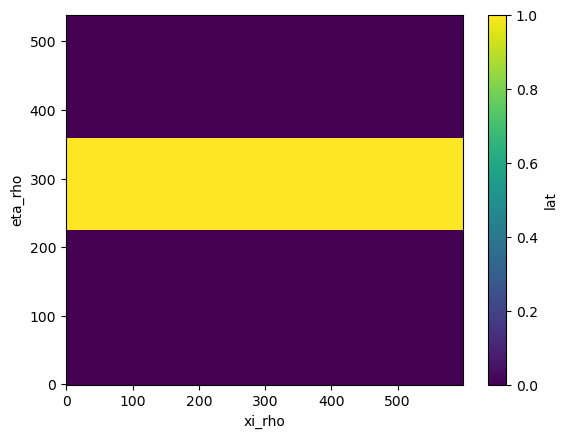

In [17]:
lat_c_da = lat_c  # at curl centers
band = (lat_c_da >= -16) & (lat_c_da <= -5)
band.plot()

In [18]:
(total_wek.isel(time=0).where(band))

# sv_wek = total_wek.sel(lat=slice(-16,-5)).sum(['lon','lat']) / 1e6

<xarray.DataArray (eta_rho: 539, xi_rho: 599)> Size: 3MB
dask.array<where, shape=(539, 599), dtype=float64, chunksize=(539, 599), chunktype=numpy.ndarray>
Coordinates:
    time     datetime64[ns] 8B 1979-12-31T21:59:59.999704524
Dimensions without coordinates: eta_rho, xi_rho

In [ ]:
sv_wek = (total_wek.where(band)).sum(dim=('eta_rho','xi_rho'))  # m^3/s
# Convert to Sv if desired:
sv_wek_Sv = sv_wek / 1e6

SV = sv_wek_Sv.sortby('time')
SV.to_netcdf('SV_pump.nc')

In [ ]:
# sv_wek_Sv.resample(time="1D").mean().plot()

SV_month = SV.resample(time='M').mean()
SV_month

In [ ]:
# SV_month = SV_month.compute()
# SV_month
SV_month.to_netcdf('monthly_SV_pump.nc')

In [ ]:
# Persist keeps data in distributed memory across workers
print("Persisting data in distributed memory...")
sv_persisted = sv_wek_Sv.persist()

# Wait for persist to complete (check the dask dashboard)
print("Waiting for persist to complete...")
from dask.distributed import wait
wait(sv_persisted)

# Now operations should be much faster
print("Computing monthly means...")
SV_month = sv_persisted.sortby('time').resample(time='M').mean()
SV_month_computed = SV_month.compute()
SV_month_computed

In [ ]:
##-- This part is not ok
# ----------------------------
# Example: mask, integrate, subset by latitude band
# ----------------------------
# If your inshore_mask is on rho grid (eta_rho, xi_rho), match to curl centers:
# inshore_mask_c = inshore_mask[:eta_c, :xi_c]

total_wek = w_ek * inshore_mask[:eta_c, :xi_c]* mask_nan[:eta_c, :xi_c] * cell_area  # units: (m/s)*m^2 = m^3/s

# Example: sum over a latitude band, say -16° to -5° (Southern Hemisphere)
lat_c_da = lat_c  # at curl centers
band = (lat_c_da >= -16) & (lat_c_da <= -5)
sv_wek = (total_wek.where(band)).sum(dim=('eta_rho','xi_rho'))  # m^3/s
# Convert to Sv if desired:
sv_wek_Sv = sv_wek / 1e6

print("Ekman pumping calculation complete!")
print(f"w_ek shape: {w_ek.shape}")
print(f"sv_wek_Sv shape: {sv_wek_Sv.shape}")

In [ ]:
# from dask.distributed import Client
# client = Client(n_workers=2, threads_per_worker=3, memory_limit=15e9)
# client

In [ ]:
# sv_wek_Sv.to_netcdf('Pump_Sv.nc')

In [ ]:
Epump = xr.open_dataset('monthly_SV_pump.nc')
Epump=Epump.compute()
Epump

In [ ]:
## Ekman transport

f = 2 * omega * np.sin(np.radians(winds_ds.lat))

U_ekman = tauy / (rho * f)

ek_t_sv = (-U_ekman * inshore_mask * delta_y).sel(lat=slice(-16,-5)).sum(dim='lat')/ 1e6